# Análisis Exploratorio del Mercado Accionario Chileno

Análisis de precios históricos de 9 acciones del IPSA distribuidas en 5 sectores (Mayo 2024 – Mayo 2026).

| Sector | Acciones |
|---|---|
| Retail | FALABELLA, CENCOSUD |
| Energía | COPEC, ENELCHILE |
| Banca | BSANTANDER, BCI |
| Minería / Forestal | CAP, CMPC |
| Utilities | AGUAS-A |

Se calculan retornos acumulados, retornos diarios, estadística descriptiva, Sharpe ratio y matriz de correlación para caracterizar el comportamiento de cada activo y sector.

In [31]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import numpy as np

## 1. Carga de datos

Descarga de precios históricos OHLCV via Yahoo Finance. Se aíslan los precios de cierre ajustados.

In [32]:
lista_nombre_acciones = ["COPEC.SN", "FALABELLA.SN", "CMPC.SN", "CENCOSUD.SN","ENELCHILE.SN", "BSANTANDER.SN", "BCI.SN","CAP.SN", "AGUAS-A.SN"]
datos_brutos_acciones = yf.download(tickers = lista_nombre_acciones, period = "2y")

[*********************100%***********************]  9 of 9 completed


In [33]:
datos_brutos_acciones.head()

Price            Close                                                        \
Ticker      AGUAS-A.SN        BCI.SN BSANTANDER.SN       CAP.SN  CENCOSUD.SN   
Date                                                                           
2024-05-15  244.372162  25617.787109     40.972973  6851.000000  1770.202881   
2024-05-16  244.499878  25263.626953     40.828449  6785.000000  1761.346924   
2024-05-17  245.029022  25853.898438     40.367771  6670.100098  1771.580444   
2024-05-20  248.459320  25613.064453     40.331642  6665.000000  1815.368164   
2024-05-22  249.061462  25499.734375     40.828449  6586.000000  1815.466553   

Price                                                                 High  \
Ticker          CMPC.SN     COPEC.SN ENELCHILE.SN FALABELLA.SN  AGUAS-A.SN   
Date                                                                         
2024-05-15  1888.693970  7226.270508    50.189449  2626.310303  246.315393   
2024-05-16  1893.750244  7137.905762    48.949059  2631.111328  245.859215   
2024-05-17  1933.308838  7313.654297    48.012436  2688.727051  245.412206   
2024-05-20  1913.479980  7242.274902    48.442772  2718.495117  249.928158   
2024-05-22  1898.608398  7481.546875    48.518723  2669.521729  249.973775   

Price       ...         Open     Volume                              \
Ticker      ... FALABELLA.SN AGUAS-A.SN BCI.SN BSANTANDER.SN CAP.SN   
Date        ...                                                       
2024-05-15  ...  2626.310303     357219  18876      60657812  50982   
2024-05-16  ...  2631.111328    2612021  36968      31498703  51281   
2024-05-17  ...  2688.727051     271900  19445      19245598  12258   
2024-05-20  ...  2718.495117      80759  16812       6945155  15883   
2024-05-22  ...  2669.521729     290759  17060      18779235  48101   

Price                                                              
Ticker     CENCOSUD.SN CMPC.SN COPEC.SN ENELCHILE.SN FALABELLA.SN  
Date                                                               
2024-05-15      341799  207898    46812      5292982       155806  
2024-05-16     1238867  363220   261439     10084716       294253  
2024-05-17      640811  744388   184210     11945645       310075  
2024-05-20      175417   98616    38906      2411038       159951  
2024-05-22      253585  539541   159421     13089720       463567  

[5 rows x 45 columns]

In [34]:
precios_cierre = datos_brutos_acciones["Close"]
precios_cierre

Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN
Date,,,,,,,,,
2024-05-15,244.372162,25617.787109,40.972973,6851.000000,1770.202881,1888.693970,7226.270508,50.189449,2626.310303
2024-05-16,244.499878,25263.626953,40.828449,6785.000000,1761.346924,1893.750244,7137.905762,48.949059,2631.111328
2024-05-17,245.029022,25853.898438,40.367771,6670.100098,1771.580444,1933.308838,7313.654297,48.012436,2688.727051
2024-05-20,248.459320,25613.064453,40.331642,6665.000000,1815.368164,1913.479980,7242.274902,48.442772,2718.495117
2024-05-22,249.061462,25499.734375,40.828449,6586.000000,1815.466553,1898.608398,7481.546875,48.518723,2669.521729
...,...,...,...,...,...,...,...,...,...
2026-05-11,334.989990,58010.000000,66.750000,7170.000000,2115.000000,1143.599976,6190.000000,78.153976,5620.000000
2026-05-12,332.980011,57126.000000,68.260002,7005.600098,2055.100098,1110.000000,6180.000000,76.947899,5535.000000
2026-05-13,328.000000,55747.000000,67.489998,6730.000000,2083.100098,1100.000000,6143.500000,75.741814,5380.000000


## 2. Retornos acumulados y comparación de rendimiento

Los precios se normalizan a base 100 en la fecha de inicio para hacer comparables activos con distintos niveles de precio absoluto. La diferencia respecto a 100 corresponde al retorno porcentual acumulado desde mayo 2024.

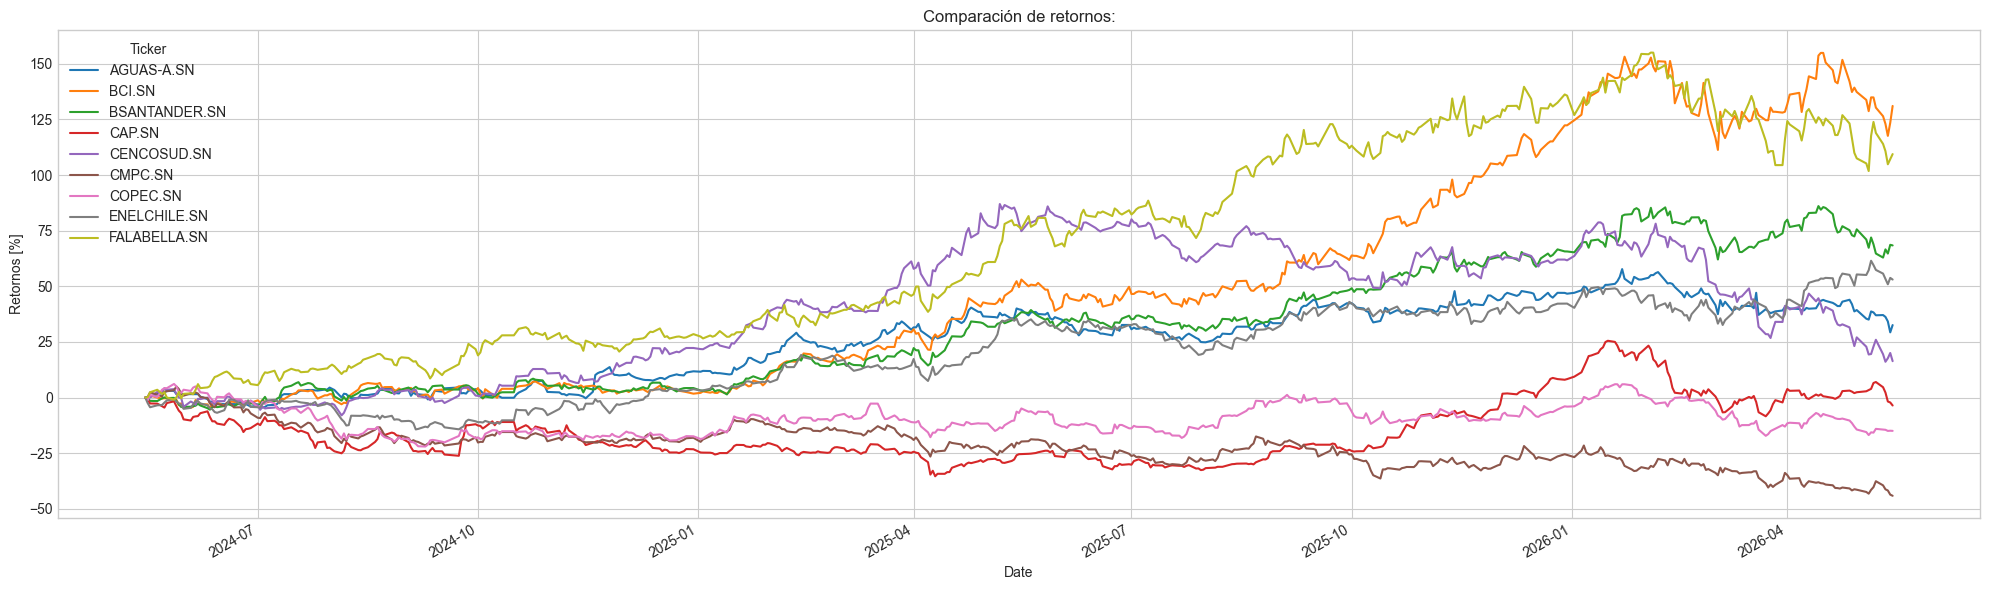

In [35]:
precios_normalizados = precios_cierre/precios_cierre.iloc[0]*100
retornos_en_tiempo = precios_normalizados - 100
plt.style.use('seaborn-v0_8-whitegrid')
fig, rt_g = plt.subplots(figsize=(20, 6))
rt_g.set_title('Comparación de retornos:')
rt_g.set_xlabel("Fecha")
rt_g.set_ylabel("Retornos [%]")
retornos_en_tiempo.plot(ax=rt_g)
plt.tight_layout()

## 3. Retornos diarios y estadística descriptiva

Los retornos diarios se calculan con `pct_change()` sobre los precios de cierre. Se reportan media, volatilidad (desviación estándar), ratio de Sharpe simplificado (retorno/volatilidad, sin tasa libre de riesgo) y exceso de kurtosis como indicador de fat tails.

In [36]:
retornos_diarios = precios_cierre.pct_change()
retornos_diarios

Ticker,AGUAS-A.SN,BCI.SN,BSANTANDER.SN,CAP.SN,CENCOSUD.SN,CMPC.SN,COPEC.SN,ENELCHILE.SN,FALABELLA.SN
Date,,,,,,,,,
2024-05-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-16,0.000523,-0.013825,-0.003527,-0.009634,-0.005003,0.002677,-0.012228,-0.024714,0.001828
2024-05-17,0.002164,0.023364,-0.011283,-0.016934,0.005810,0.020889,0.024622,-0.019135,0.021898
2024-05-20,0.014000,-0.009315,-0.000895,-0.000765,0.024717,-0.010256,-0.009760,0.008963,0.011071
2024-05-22,0.002424,-0.004425,0.012318,-0.011853,0.000054,-0.007772,0.033038,0.001568,-0.018015
...,...,...,...,...,...,...,...,...,...
2026-05-11,0.000747,-0.016780,-0.011111,-0.021828,-0.051570,-0.029943,-0.003221,-0.010506,-0.022609
2026-05-12,-0.006000,-0.015239,0.022622,-0.022929,-0.028321,-0.029381,-0.001616,-0.015432,-0.015125
2026-05-13,-0.014956,-0.024140,-0.011280,-0.039340,0.013625,-0.009009,-0.005906,-0.015674,-0.028004


In [45]:
sharpe = retornos_diarios.mean()/retornos_diarios.std()
media = retornos_diarios.mean()
dst = retornos_diarios.std()

pd.DataFrame({"Media" : media,"Desviación Estandar" : dst, "Ratio de Sharpe" : sharpe, "Porcentaje de Retorno" : retornos_en_tiempo.iloc[-1], "Kurtosis" : retornos_diarios.kurt()}).sort_values("Porcentaje de Retorno", ascending = False)

,Media,Desviación Estandar,Ratio de Sharpe,Porcentaje de Retorno,Kurtosis
Ticker,,,,,
BCI.SN,0.001819,0.015878,0.114542,131.062112,1.509381
FALABELLA.SN,0.001637,0.016892,0.096883,109.426898,1.063128
BSANTANDER.SN,0.001132,0.012537,0.090253,68.379283,1.222325
ENELCHILE.SN,0.000960,0.014187,0.067681,53.040128,1.010133
AGUAS-A.SN,0.000645,0.012266,0.052581,32.584660,5.123712
CENCOSUD.SN,0.000442,0.016487,0.026796,16.370842,1.684088
CAP.SN,0.000064,0.016596,0.003870,-3.554226,2.651489
COPEC.SN,-0.000215,0.014986,-0.014375,-14.963051,0.388698
CMPC.SN,-0.001028,0.017233,-0.059647,-44.141295,0.528182


## 4. Distribución de retornos — leptokurtosis

Se compara la distribución empírica de retornos (KDE) con la distribución normal teórica de igual media y desviación estándar para cada acción. Las diferencias entre ambas curvas revelan si los retornos presentan colas más gruesas de lo que la normal predice.

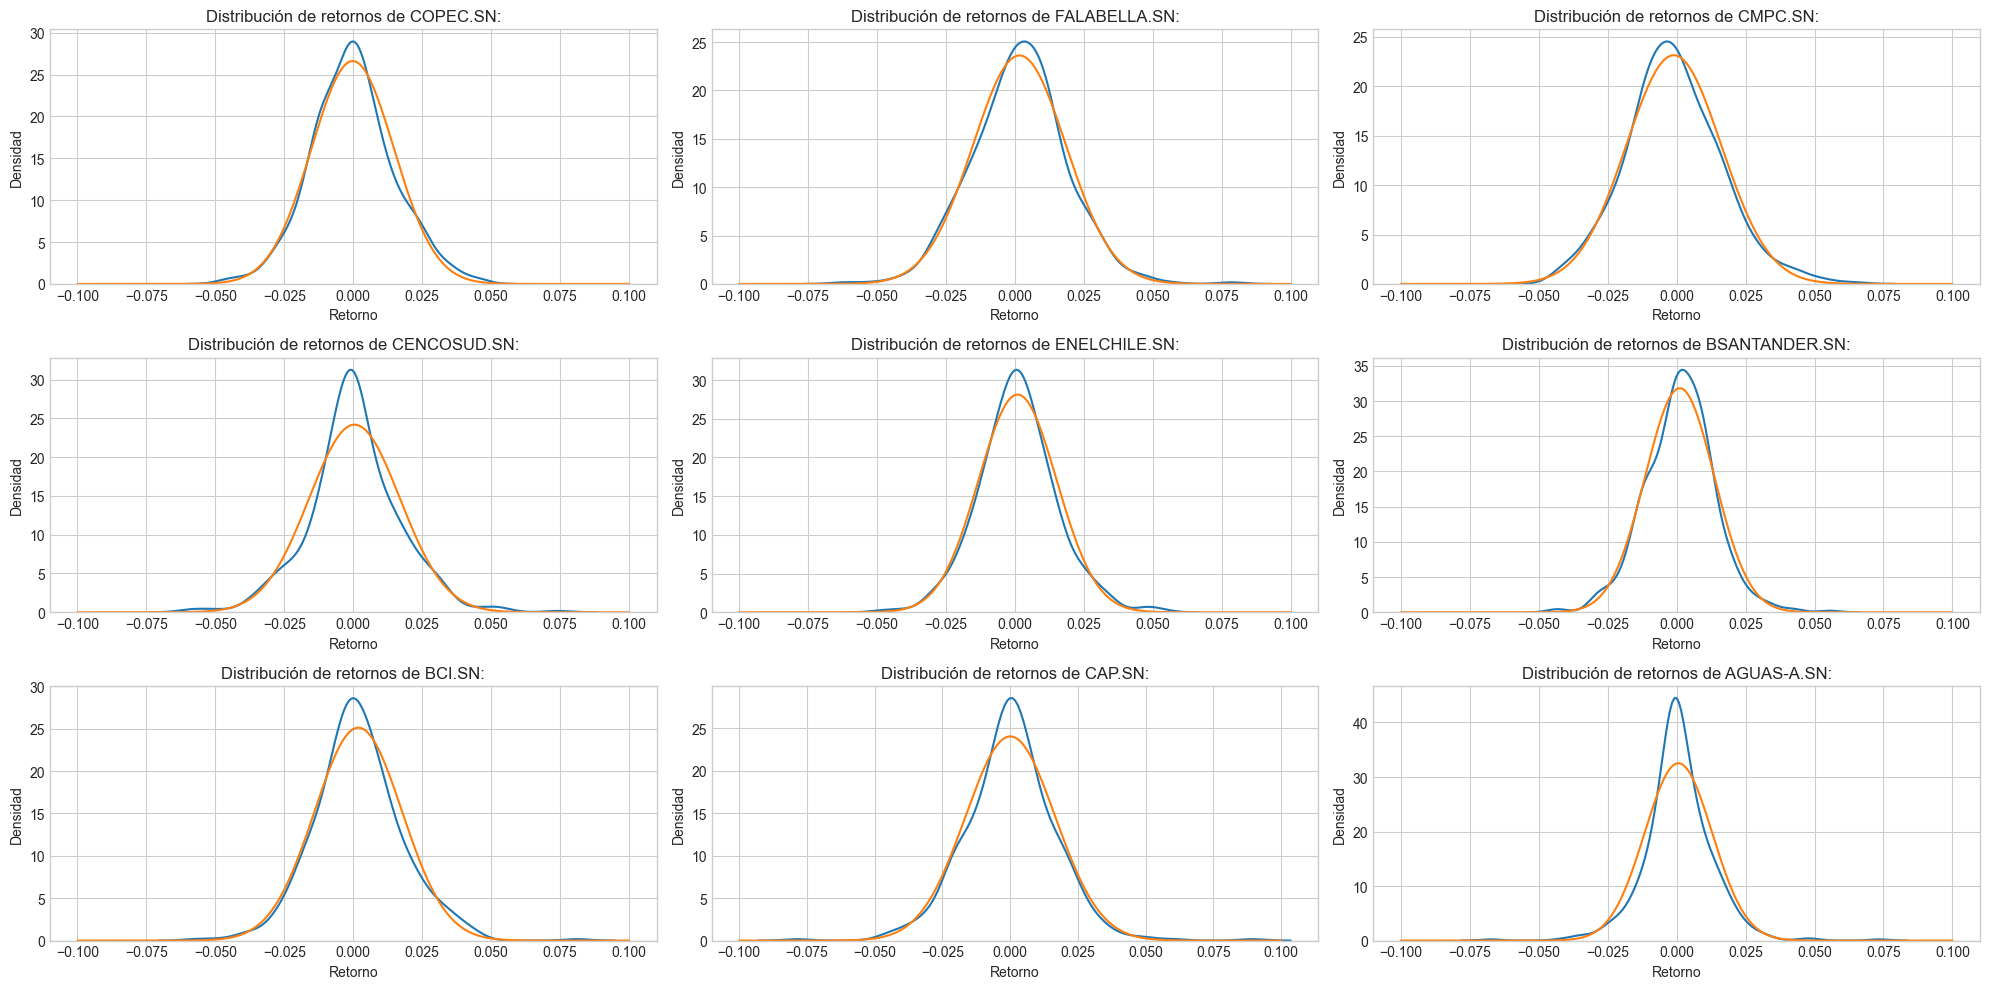

In [38]:
fig, gauss_retornos = plt.subplots(3, 3, figsize=(20, 10))
x = 0
y = 0

for i in lista_nombre_acciones:
    x_valores = np.linspace(-0.1, 0.1, 1000)
    densidad_normal = norm.pdf(x_valores, loc=media[i], scale=dst[i])
    sns.kdeplot(retornos_diarios[i], ax = gauss_retornos[x][y])
    gauss_retornos[x][y].set_title("Distribución de retornos de " + i + ":")
    gauss_retornos[x][y].set_ylabel("Densidad")
    gauss_retornos[x][y].set_xlabel("Retorno")
    plt.tight_layout()
    gauss_retornos[x][y].plot(x_valores, densidad_normal)
    if y == 2:
        y = 0
        x += 1
    else:
        y += 1


## 5. Autocorrelación de retornos y eficiencia de mercado

Se grafica el retorno del día `t` contra el retorno del día `t+1` para cada acción. La existencia de estructura en el scatter indicaría que el retorno de hoy predice el de mañana — lo cual sería inconsistente con la Hipótesis de Mercado Eficiente (EMH) en su forma débil.

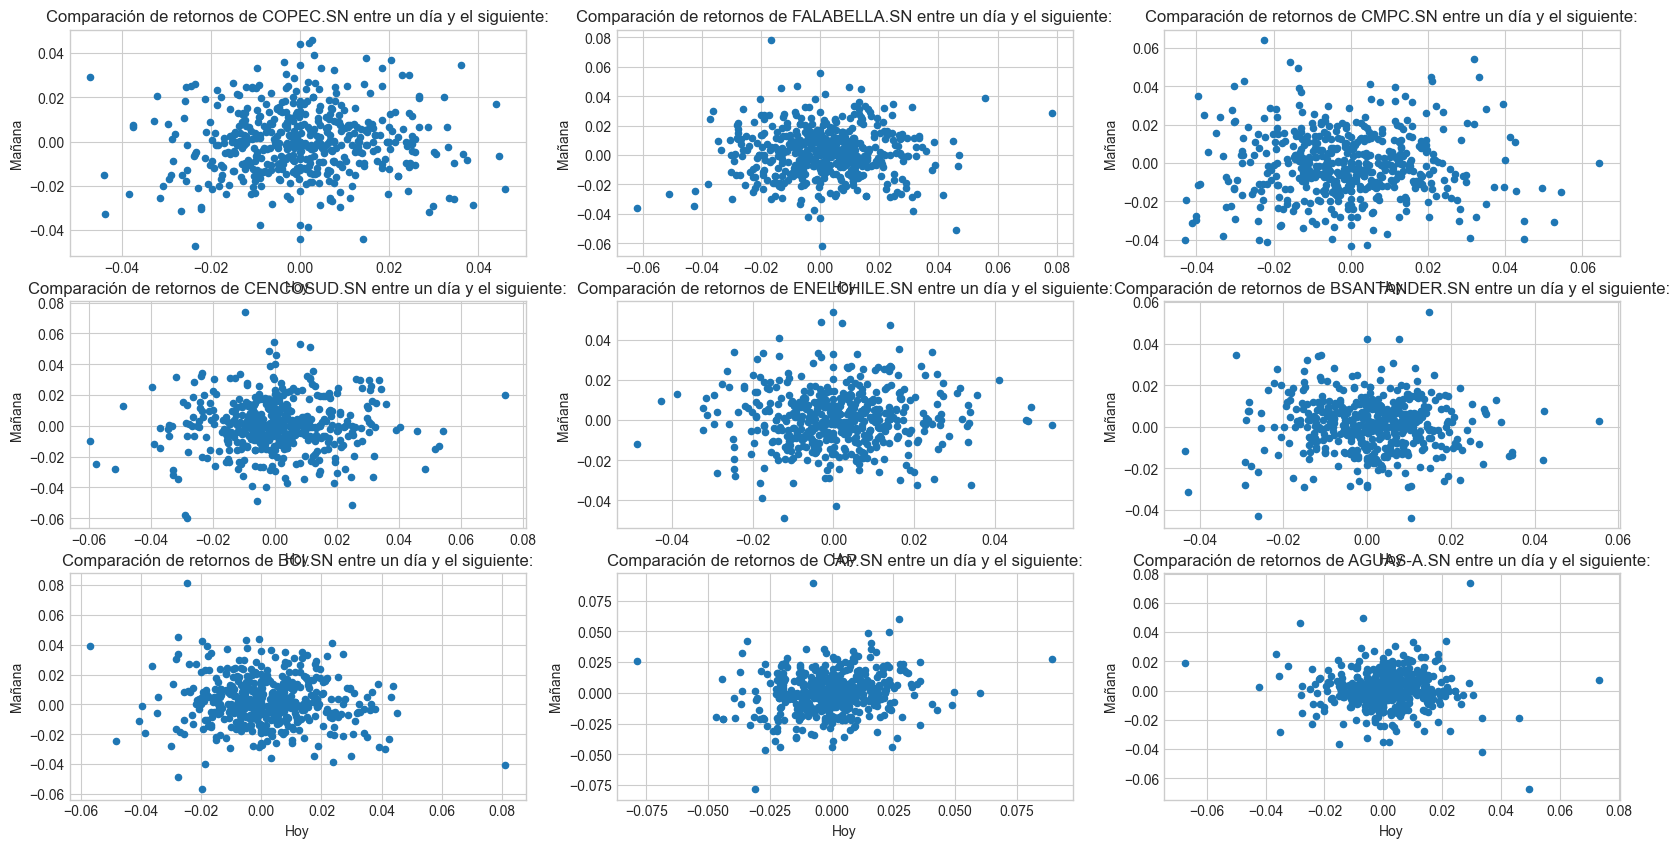

In [40]:
x = 0
y = 0
fig, comparacion_retorno_hoy_mañana = plt.subplots(3, 3, figsize=(20, 10))
for i in lista_nombre_acciones:    
    retornos_dia_siguiente_ac_es = retornos_diarios[i].shift(-1)
    retornos_diarios_ac_es = retornos_diarios[i]
    comparacion_retorno_hoy_mañana[x][y].set_title("Comparación de retornos de "+ i +" entre un día y el siguiente:")
    comparacion_ax = pd.DataFrame({"Hoy" : retornos_diarios_ac_es, "Mañana" : retornos_dia_siguiente_ac_es})
    comparacion_ax.plot.scatter(x = "Hoy", y = "Mañana", ax = comparacion_retorno_hoy_mañana[x][y])

    if y < 2:
        y += 1
    else:
        x += 1
        y = 0
    

## 6. Agrupamiento de volatilidad

A diferencia de los retornos, la magnitud de los movimientos puede ser persistente. Se grafica el valor absoluto del retorno del día `t` contra el del día `t+1` para detectar si los días volátiles tienden a agruparse con otros días volátiles.

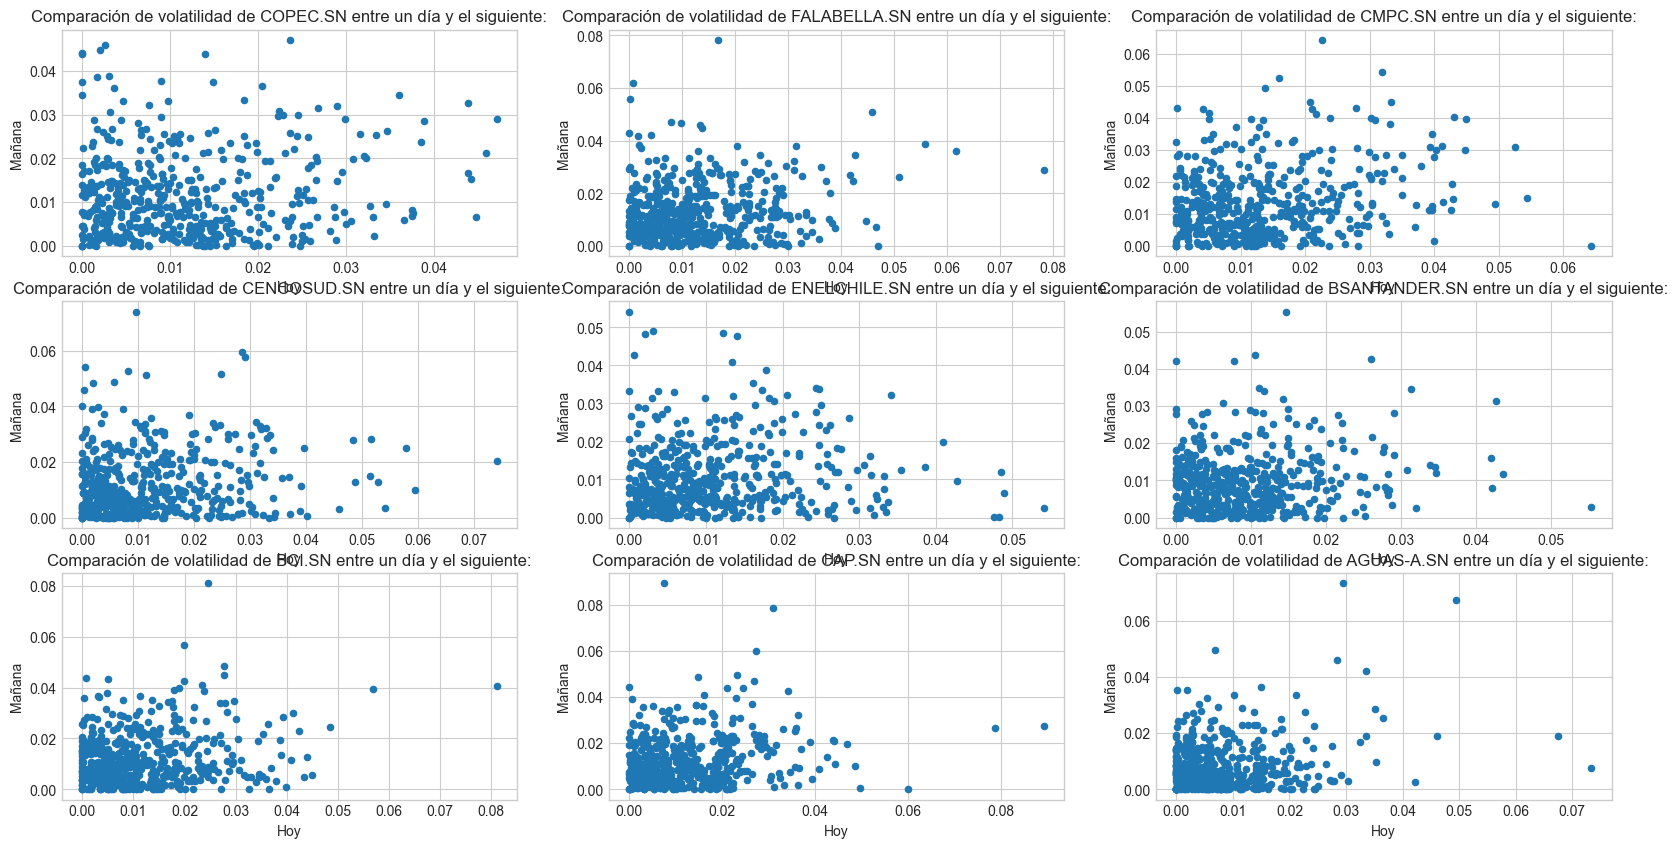

In [41]:
volatilidad_diarios = abs(retornos_diarios)
x = 0
y = 0
fig, comparacion_volatilidad_hoy_mañana = plt.subplots(3, 3, figsize=(20, 10))
for i in lista_nombre_acciones:    
    volatilidad_dia_siguiente_ac_es = volatilidad_diarios[i].shift(-1)
    volatilidad_diarios_ac_es = volatilidad_diarios[i]
    comparacion_volatilidad_hoy_mañana[x][y].set_title("Comparación de volatilidad de "+ i +" entre un día y el siguiente:")
    comparacion_ax = pd.DataFrame({"Hoy" : volatilidad_diarios_ac_es, "Mañana" : volatilidad_dia_siguiente_ac_es})
    comparacion_ax.plot.scatter(x = "Hoy", y = "Mañana", ax = comparacion_volatilidad_hoy_mañana[x][y])

    if y < 2:
        y += 1
    else:
        x += 1
        y = 0

## 7. Variación de retornos entre días no consecutivos

Se analiza si la aceleración del retorno en un par de días predice la aceleración en el siguiente par. Se usa una ventana sin solapamiento (`r_{t+1} - r_t` vs `r_{t+3} - r_{t+2}`) para evitar correlación espuria matemática por términos compartidos.

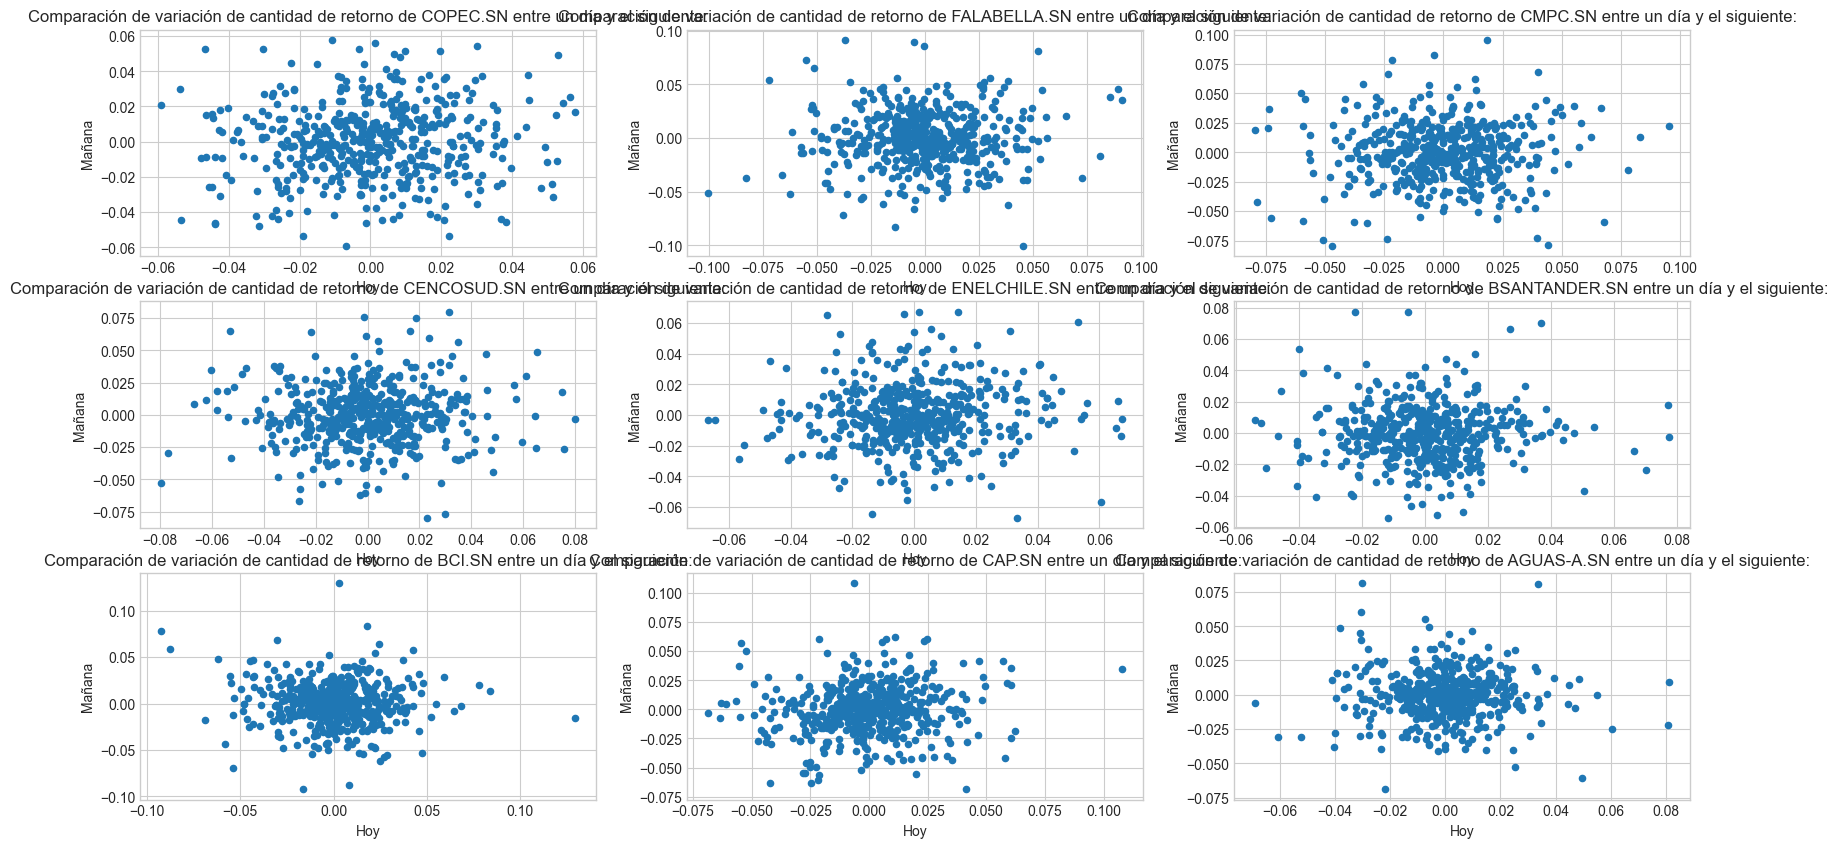

In [ ]:
var_diarios = (retornos_diarios.shift(-2) - retornos_diarios)
x = 0
y = 0
fig, comparacion_var_hoy_mañana = plt.subplots(3, 3, figsize=(20, 10))
for i in lista_nombre_acciones:    
    var_dia_siguiente_ac_es = var_diarios[i].shift(-1)
    var_diarios_ac_es = var_diarios[i]
    comparacion_var_hoy_mañana[x][y].set_title("Comparación de variación de cantidad de retorno de "+ i +" entre un día y el siguiente:")
    comparacion_ax = pd.DataFrame({"Hoy" : var_diarios_ac_es, "Mañana" : var_dia_siguiente_ac_es})
    comparacion_ax.plot.scatter(x = "Hoy", y = "Mañana", ax = comparacion_var_hoy_mañana[x][y])

    if y < 2:
        y += 1
    else:
        x += 1
        y = 0

## 8. Correlación entre activos

La correlación entre retornos diarios mide qué tan relacionados están los movimientos de precio entre pares de activos. Valores cercanos a 1 indican que se mueven juntos; cercanos a 0, independencia. La estructura sectorial en la matriz orienta la diversificación del portafolio.

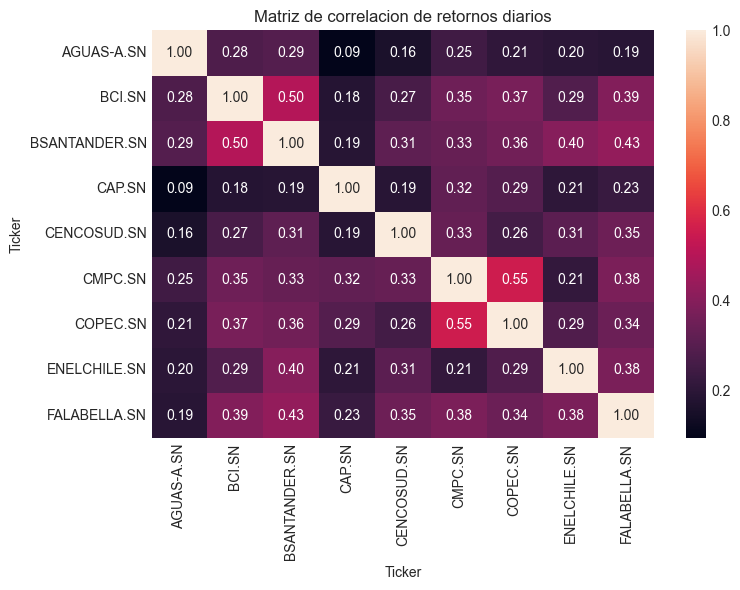

In [43]:
plt.figure(figsize=(8, 6))
sns.heatmap(retornos_diarios.corr(), annot=True, fmt=".2f")
plt.title("Matriz de correlacion de retornos diarios")
plt.tight_layout()

## 9. Conclusiones

### 9.1 Distribución de retornos — leptokurtosis

La comparación entre la distribución empírica (KDE) y la normal teórica revela que todas las acciones presentan **exceso de kurtosis positivo** (leptokurtosis): distribuciones más picudas y con colas más gruesas que una normal con la misma media y desviación estándar.

| Acción | Kurtosis (exceso) |
|---|---|
| AGUAS-A.SN | 5.12 |
| CAP.SN | 2.65 |
| CENCOSUD.SN | 1.68 |
| BCI.SN | 1.51 |
| BSANTANDER.SN | 1.22 |
| FALABELLA.SN | 1.06 |
| ENELCHILE.SN | 1.01 |
| CMPC.SN | 0.53 |
| COPEC.SN | 0.39 |

**Implicación financiera:** los modelos de riesgo basados en distribución normal (como el VaR paramétrico) subestiman la probabilidad de eventos extremos. Las colas más gruesas implican que caídas abruptas ocurren con mayor frecuencia de lo que la normal predice — fenómeno ampliamente documentado en mercados emergentes y en crisis como la de 2008.

---

### 9.2 Eficiencia de mercado — ausencia de autocorrelación en retornos

El scatter plot de retorno del día `t` versus retorno del día `t+1` no muestra ninguna estructura en las 9 acciones analizadas: la nube de puntos es esencialmente aleatoria.

**Conclusión:** los retornos diarios del IPSA no son predecibles en base al retorno del día anterior, lo cual es consistente con la **Hipótesis de Mercado Eficiente (EMH)** en su forma débil. Si existiera correlación predecible, los participantes del mercado la explotarían mediante arbitraje hasta eliminarla, llevando el sistema a un equilibrio sin estructura.

---

### 9.3 Agrupamiento de volatilidad (*volatility clustering*)

El scatter plot de volatilidad del día `t` (`|retorno_t|`) versus volatilidad del día `t+1` (`|retorno_{t+1}|`) muestra concentración positiva: días de alta volatilidad tienden a ser seguidos por días de alta volatilidad, y días tranquilos por días tranquilos.

**Explicación:** a diferencia de la dirección del retorno, la magnitud de los movimientos sí es persistente. La información relevante para el mercado (datos macroeconómicos, resultados corporativos, eventos geopolíticos) llega en rachas, y el comportamiento de manada (*herding*) amplifica el efecto. Este patrón no es arbitrado porque la volatilidad no es directamente transable sin asumir otros riesgos. Es la base empírica de los modelos **GARCH**, que modelan la varianza condicional en el tiempo.

---

### 9.4 Correlación entre activos

La matriz de correlación muestra que los activos del mismo sector tienden a moverse de forma más coordinada entre sí. Las correlaciones más altas se observan entre las acciones del sector bancario (BSANTANDER, BCI) y entre las de retail (FALABELLA, CENCOSUD).

**Implicación para construcción de portafolios:** la diversificación es más efectiva entre sectores que dentro del mismo sector. Un portafolio concentrado en activos de alta correlación ofrece menor reducción de riesgo por activo adicional incluido — principio central de la **teoría de Markowitz**, que se desarrollará en notebooks posteriores.